<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Patricia González Todd

  El objetivo de este trabajo es caracterizar el desempeño estadístico de distintos estimadores de amplitud y frecuencia, analizando la relación entre resolución espectral y la exactitud en la medición de energía. Para evaluar este desempeño, nos enfocaremos en dos métricas fundamentales:
  
→ El Sesgo ($s$): Que nos indica qué tan alejado está el valor esperado de nuestra estimación respecto al valor real (exactitud).
  
→ La Varianza ($v$): Que mide la dispersión de las estimaciones ante diferentes realizaciones de ruido y variaciones de frecuencia (precisión).

Se simularán $R = 200$ **realizaciones** de una señal con frecuencia variable, modelada como:$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + r(n)$$Donde la frecuencia $\Omega_1$ fluctúa aleatoriamente alrededor de $\pi/2$ debido a una variable $f_r \sim U(-2, 2)$, lo que garantiza que la señal no sea siempre periódica respecto a la ventana de observación. Cada señal se pasará por distinttas ventanas, todas de $N = 1000$ **muestras** a una **frecuencia de muestreo**
$f_s = 1000$.
De este modo llenaremos una **matriz de NxR**.

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows


def mi_funcion_ruido (N, Pr):
    desvio = np.sqrt(Pr)
    r = np.random.normal(0, desvio, N) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    return r
  
# Parámetros
a0 = np.sqrt(2)
N = 1000
fs = 1000
deltaf = fs/N
W0 = np.pi/2
SNR_db = 10
Ps = (a0**2)/ 2
Pr = Ps / (10**(SNR_db/10))
R = 200

#genero las senoidales:

nn = np.arange (N)*(1/fs)
nn = nn.reshape(N,1)
matriz_n = np.tile(nn,(1,R))

fr = np.random.uniform(-2, 2, R)

f1 = (N/4 + fr) * deltaf

matriz_f = np.tile(f1, (N,1))

matriz_S = a0 * np.sin(2*np.pi* matriz_f *matriz_n) # esto es una matriz de N muestras por R de

r = mi_funcion_ruido((N,R), Pr)

matriz_Sr = matriz_S + r


Para cada ventana $w_i(n)$, definimos:

Estimador de Amplitud ($\hat{a}_1$): Evaluamos el módulo de la FFT en la frecuencia central teórica $\Omega_0 = \pi/2$ en cada realización.$$\hat{a}_{i} = \left| \mathcal{F}\{x(n) \cdot w_i(n)\} \right|_{\Omega_0}$$ 

Estimador de Frecuencia ($\hat{\Omega}_1$): Identificamos la frecuencia donde se produce el máximo valor del espectro (método argmax) en cada realización.$$\hat{\Omega}_{i} = \arg \max_{f}  \{ |X_{w_i}(\Omega)| \}$$ .
Analizaremos cuatro casos para observar el compromiso entre resolución espectral y exactitud en amplitud:

→ **Rectangular**: Máxima resolución, pero muy sensible al leakage.

→ **Flat-top**: Diseñada específicamente para minimizar el error de amplitud.

→ **Blackman-Harris**: Excelente supresión de lóbulos secundarios.

→ **Hann**: Una ventana de propósito general con buen balance.

Dado que la multiplicación en el dominio del tiempo equivale a una convolución en el dominio de la frecuencia, presento primero el espectro de cada ventana. Esto facilitará la comprensión de los gráficos espectrales presentados más adelante.

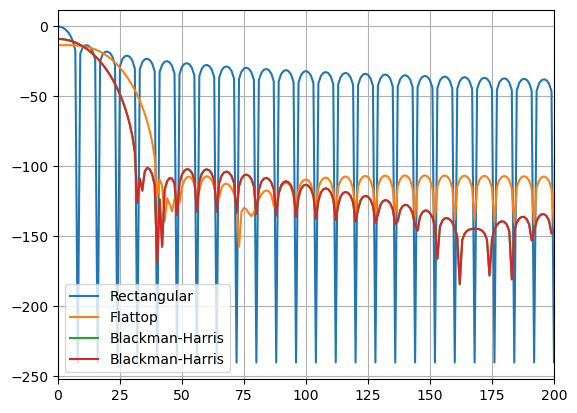

In [72]:
# %% Espectro de las ventanas 
W1 = np.fft.fft(np.ones(N), n=N*8) #con zero padding
W2 = np.fft.fft(windows.flattop(N), n=N*8)
W3 = np.fft.fft(windows.blackmanharris(N), n=N*8)
W4 = np.fft.fft(windows.hann(N), n=N*8)

W1_db = 20*np.log10(np.abs(W1)/N + 1e-12)
W2_db = 20*np.log10(np.abs(W2)/N + 1e-12)
W3_db = 20*np.log10(np.abs(W3)/N + 1e-12)
W4_db = 20*np.log10(np.abs(W3)/N + 1e-12)

plt.plot(W1_db, label='Rectangular')
plt.plot(W2_db, label='Flattop')
plt.plot(W3_db, label='Blackman-Harris')
plt.plot(W4_db, label='Blackman-Harris')

plt.xlim(0, 200)
plt.legend()
plt.grid()
plt.show()

Podemos evidenciar diferencias entre atenuaciones y lobulos principales en cada ventana, esto condicionará los espectros de las senoidales de la siguiente manera:

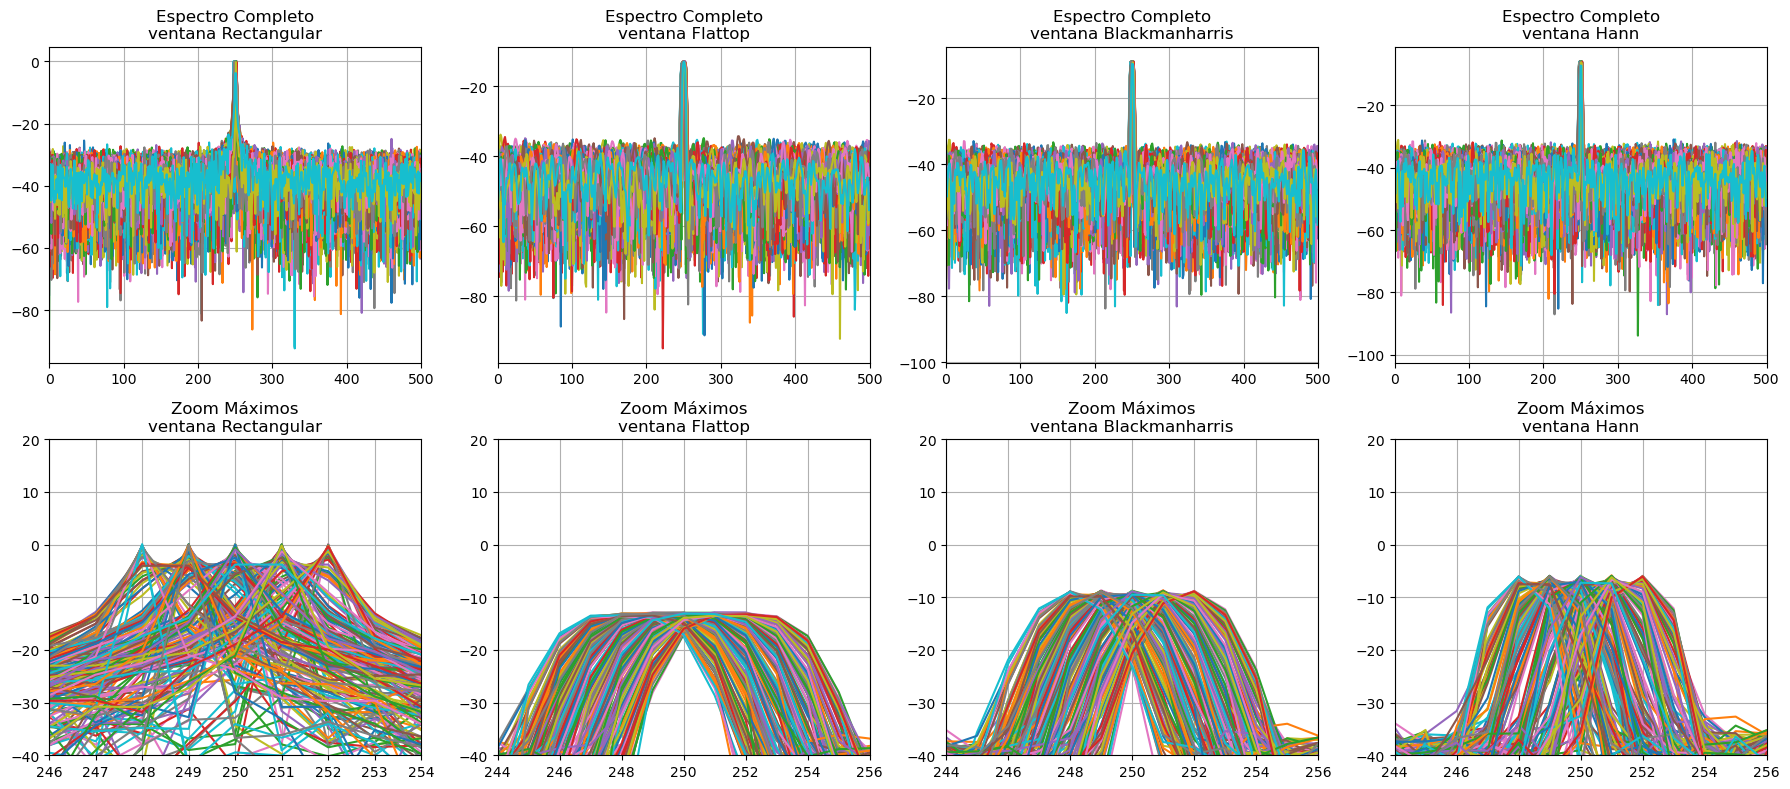

In [73]:

# %% SIN VENTANA

w1 = np.ones(N)
w1 = w1.reshape(N,1)
w1 = np.tile(w1, (1,R))

x1 = np.fft.fft(matriz_Sr,n=N,axis=0)/(N)  # normalizada con las muestras

mag_x1 = np.abs(x1[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x1 = (np.abs(x1)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x1_db = 10*np.log10(pot_x1[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf


'''HASTA ACA SE QUE ESTOY ENTRE -2 Y 2'''


# %% VENTANA FLATTOP

w2 = windows.flattop(N)
w2 = w2.reshape(N,1)
w2 = np.tile(w2, (1,R))

x2 = np.fft.fft((matriz_Sr*w2),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x2 = np.abs(x2[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x2 = (np.abs(x2)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x2_db = 10*np.log10(pot_x2[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf


'''HASTA ACA SE QUE ESTOY ENTRE -2 Y 2'''

# %% VENTANA Blackmanharris

w3 = windows.blackmanharris(N)
w3 = w3.reshape(N,1)
w3 = np.tile(w3, (1,R))

x3 = np.fft.fft((matriz_Sr*w3),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x3 = np.abs(x3[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x3 = (np.abs(x3)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x3_db = 10*np.log10(pot_x3[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% VENTANA Hann

w4 = windows.hann(N)
w4 = w4.reshape(N,1)
w4 = np.tile(w4, (1,R))

x4 = np.fft.fft((matriz_Sr*w4),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x4 = np.abs(x4[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x4 = (np.abs(x4)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x4_db = 10*np.log10(pot_x4[:N//2, :] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% Grafico comparativo con zoom en los maximos

fig, axes = plt.subplots(2, 4, figsize=(18, 8)) 

# Desempaquetamos usando .flatten() para asignar cada celda a tus variables de forma lineal
Rec, Flat, Black, Hann, Recz, Flatz, Blackz, Hannz = axes.flatten()

# Creamos el vector de frecuencias correcto para el espectro unilateral (500 puntos)
ffreq_unilateral = np.arange(0, N//2) * deltaf

# ==========================================
# FILA 1: ESPECTRO COMPLETO (0 a fs/2)
# ==========================================

# --- Ventana Rectangular ---
Rec.plot(ffreq_unilateral, pot_x1_db) 
Rec.set_xlim(0, fs/2)
Rec.set_title("Espectro Completo\nventana Rectangular")
Rec.grid(True)

# --- Ventana Flattop ---
Flat.plot(ffreq_unilateral, pot_x2_db) 
Flat.set_xlim(0, fs/2)
Flat.set_title("Espectro Completo\nventana Flattop")
Flat.grid(True)

# --- Ventana Blackmanharris ---
Black.plot(ffreq_unilateral, pot_x3_db) 
Black.set_xlim(0, fs/2)
Black.set_title("Espectro Completo\nventana Blackmanharris")
Black.grid(True)

# --- Ventana Hann ---
Hann.plot(ffreq_unilateral, pot_x4_db) 
Hann.set_xlim(0, fs/2) # CORREGIDO: Era set_xlim, no set_lim
Hann.set_title("Espectro Completo\nventana Hann")
Hann.grid(True)


# ==========================================
# FILA 2: ZOOM EN LOS MÁXIMOS
# ==========================================

# --- Ventana Rectangular (Zoom) ---
Recz.plot(ffreq_unilateral, pot_x1_db) 
Recz.set_xlim(N/4 * deltaf - 4*deltaf, N/4 * deltaf + 4*deltaf) 
Recz.set_ylim(-40, 20) 
Recz.set_title("Zoom Máximos\nventana Rectangular")
Recz.grid(True)

# --- Ventana Flattop (Zoom) ---
Flatz.plot(ffreq_unilateral, pot_x2_db) 
Flatz.set_xlim(N/4 * deltaf - 6*deltaf, N/4 * deltaf + 6*deltaf)
Flatz.set_ylim(-40, 20)
Flatz.set_title("Zoom Máximos\nventana Flattop")
Flatz.grid(True)

# --- Ventana Blackmanharris (Zoom) ---
Blackz.plot(ffreq_unilateral, pot_x3_db) 
Blackz.set_xlim(N/4 * deltaf - 6*deltaf, N/4 * deltaf + 6*deltaf)
Blackz.set_ylim(-40, 20)
Blackz.set_title("Zoom Máximos\nventana Blackmanharris")
Blackz.grid(True)

# --- Ventana Hann (Zoom) ---
Hannz.plot(ffreq_unilateral, pot_x4_db) 
Hannz.set_xlim(N/4 * deltaf - 6*deltaf, N/4 * deltaf + 6*deltaf)
Hannz.set_ylim(-40, 20)
Hannz.set_title("Zoom Máximos\nventana Hann")
Hannz.grid(True)

plt.tight_layout()
plt.show()




Al observar el espectro de las ventanas, se hace evidente el compromiso fundamental del que hablamos: ancho del lóbulo principal vs. nivel de lóbulos secundarios.

**→ La rectangular** tiene el lóbulo principal más angosto (mejor resolución frecuencial), pero sus lóbulos secundarios caen apenas ~13 dB respecto al pico. Esto significa que si hay dos señales cercanas, o si la frecuencia no cae exactamente en un bin, la energía "se derrama" significativamente hacia los bins vecinos.

**→La Flat-top** muestra el lóbulo principal notablemente más ancho, lo cual implica peor resolución pero una cresta casi plana. Esta planitud es justamente su ventaja: el valor de la FFT en Ω₀ varía muy poco ante pequeños desplazamientos de frecuencia, lo que la hace ideal para estimar amplitudes.

**→La Blackman-Harris** ofrece una caída de lóbulos secundarios mucho más pronunciada (por debajo de -90 dB), con un lóbulo principal de ancho intermedio. Es la opción preferida cuando importa más suprimir interferencias espectrales que tener máxima resolución.

**→La Hann** se ubica como punto medio práctico: mejor supresión de lóbulos que la rectangular y mejor resolución que la Blackman-Harris, a costa de un compromiso en ambos frentes.

Al mirar los espectros de las señales con zoom en la zona de 250 Hz, estos comportamientos se traducen directamente: la rectangular muestra realizaciones con amplitudes muy dispersas (el leakage afecta cada realización de forma distinta según dónde caiga fr), mientras que la Flat-top muestra picos más consistentes en altura aunque sistemáticamente atenuados por la falta de corrección de ganancia coherente.

### Analisis estadistico:
Ahora pasaremos a un analisis en histogramas de los dos estimadores que mencionamos el principio del trabajo,: la amplitud de cada realización en la frecuencia central teórica (en este caso trabajamos en frecuencias y la traducimos $\Omega_0 = \pi/2$ → $k = N/4$ ) y las pocisiones en frecuencia de de sus máximos, sabiendo que pertenecen al rango definido por $f_r \sim U(-2, 2)$.

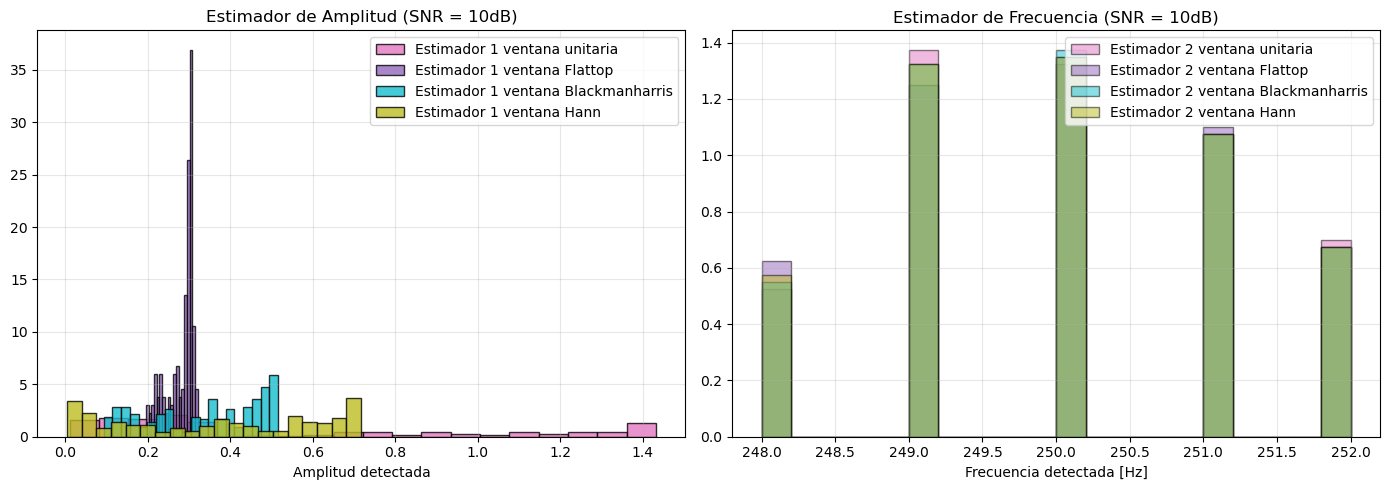

In [76]:
# %% Estimadores

#para mi primer estimador lo que quiero es ver que hay en la feta de omega 0
a1_x1 = mag_x1[int(N/4), :]
a1_x2 = mag_x2[int(N/4), :]
a1_x3 = mag_x3[int(N/4), :]
a1_x4 = mag_x4[int(N/4), :]

#quiero llegar a una matriz de rx4 de ahi hago el histograma, ese 4 son las 4 ventanas que quiero probar

'''
SEGUNDO ESTIMADOR -> AHORA TRABAJO EL ARGUMENTO
quiero quedarme con los maximos, osea todos los argumosntos N/4
aca llo que quiero es ver todos los maximos
hay lit una funcion que es argmax  y ese va a ser mi estimador (omega sombrerito),
 luego el sesgo es omega sombrerito menos omega
 quiero detectar esos maximos y por si acaso verificar que  esten bien
'''
sigma1_x1 = np.argmax(mag_x1, axis = 0)*deltaf
sigma1_x2 = np.argmax(mag_x2 , axis = 0)*deltaf
sigma1_x3 = np.argmax(mag_x3 , axis = 0)*deltaf
sigma1_x4 = np.argmax(mag_x4 , axis = 0)*deltaf

#%% Hitogramas

fig, (Ha, Hf) = plt.subplots(1, 2, figsize=(14, 5))

# amplitud 
Ha.hist(a1_x1, bins=20, density=True, alpha=0.8, edgecolor='black',color = 'C6', label = "Estimador 1 ventana unitaria")
Ha.hist(a1_x2, bins=20, density=True, alpha=0.8, edgecolor='black',color = 'C14', label = "Estimador 1 ventana Flattop")
Ha.hist(a1_x3 , bins=20, density=True, alpha=0.8, edgecolor='black',color = 'C9', label = "Estimador 1 ventana Blackmanharris")
Ha.hist(a1_x4 , bins=20, density=True, alpha=0.8, edgecolor='black',color = 'C8', label = "Estimador 1 ventana Hann")

Ha.set_title(f'Estimador de Amplitud (SNR = {SNR_db}dB)')
Ha.set_xlabel('Amplitud detectada')
Ha.legend()
Ha.grid(alpha=0.3)

# Hitograma freq 
Hf.hist(sigma1_x1 , bins=20, density=True, alpha=0.5, edgecolor='black',color = 'C6', label = "Estimador 2 ventana unitaria")
Hf.hist(sigma1_x2 , bins=20, density=True, alpha=0.5, edgecolor='black',color = 'C14', label = "Estimador 2 ventana Flattop")
Hf.hist(sigma1_x3 , bins=20, density=True, alpha=0.5, edgecolor='black', color = 'C9', label = "Estimador 2 ventana Blackmanharris")
Hf.hist(sigma1_x4 , bins=20, density=True, alpha=0.5, edgecolor='black', color = 'C8', label = "Estimador 2 ventana Hann")

Hf.set_title(f'Estimador de Frecuencia (SNR = {SNR_db}dB)')
Hf.set_xlabel('Frecuencia detectada [Hz]')
Hf.legend()
Hf.grid(alpha=0.3)

plt.tight_layout()
plt.show()



Los histogramas permiten una primera comparación intuitiva entre estimadores. Para el estimador de amplitud, se observa que la Flat-top presenta la distribución más concentrada, con un pico estrecho alrededor de ~ 0.3, lo que indica baja varianza pero un sesgo considerable respecto al valor real a0 ≈ 1.41. La Blackman-Harris se comporta de forma similar aunque con una dispersión levemente mayor. La Hann se distribuye entre 0 y 0.7 aproximadamente, ocupando una posición intermedia. La Rectangular es la más dispersa de todas, con valores que llegan hasta 1.4, anticipando el compromiso entre sesgo y varianza que cuantificaremos a continuación.

Luego, en el estimador de frecuencias se puede notar que las cuatro ventanas detectan frecuencias en el rango esperado de 248 a 252 Hz. La Rectangular, Flat-top y Blackman-Harris muestran distribuciones concentradas en pocos bins. La Hann se comporta de forma similar a la Blackman-Harris, concentrándose en los bins centrales del rango esperado, ocupando una posición intermedia entre la Rectangular y la Flat-top."

Corroboraremos los valores de sesgo y varianza en una tabla comparaiva entre ventanas y para cada estimador:

In [75]:
# %% ANALISIS
# --- SESGOS Y VARIANZAS ---

# 1. Rectangular

var_a1_x1 = np.var(a1_x1)
var_s1_x1 = np.var(sigma1_x1)
sesgo_a1_x1 = np.mean(a1_x1) - a0
sesgo_s1_x1 = np.mean(sigma1_x1 - f1)

# 2. Flat-top

var_a1_x2 = np.var(a1_x2)
var_s1_x2 = np.var(sigma1_x2)
sesgo_a1_x2 = np.mean(a1_x2) - a0
sesgo_s1_x2 = np.mean(sigma1_x2 -f1)

# 3. Blackman-Harris

var_a1_x3 = np.var(a1_x3)
var_s1_x3 = np.var(sigma1_x3)
sesgo_a1_x3 = np.mean(a1_x3) - a0
sesgo_s1_x3 = np.mean(sigma1_x3 - f1)

# 4. Hann

var_a1_x4 = np.var(a1_x4)
var_s1_x4 = np.var(sigma1_x4)
sesgo_a1_x4 = np.mean(a1_x4) - a0
sesgo_s1_x4 = np.mean(sigma1_x4 - f1)

# Estructura para la tabla
resultados = [
    ["Rectangular", sesgo_a1_x1, var_a1_x1, sesgo_s1_x1, var_s1_x1],
    ["Flat-top",    sesgo_a1_x2, var_a1_x2, sesgo_s1_x2, var_s1_x2],
    ["Blackman-H",  sesgo_a1_x3, var_a1_x3, sesgo_s1_x3, var_s1_x3],
    ["hann",  sesgo_a1_x4, var_a1_x4, sesgo_s1_x4, var_s1_x4]
    
]
print(f"Tabla comparativa para un SNR_db = {SNR_db}\n")

print(f"{'Ventana':<15} | {'Sesgo Amp':<10} | {'Var Amp':<10} | {'Sesgo Freq':<10} | {'Var Freq':<10}")
print("-" * 75)
for r in resultados:
    print(f"{r[0]:<15} | {r[1]:10.4f} | {r[2]:10.4f} | {r[3]:10.4f} | {r[4]:10.4f}")

Tabla comparativa para un SNR_db = 10

Ventana         | Sesgo Amp  | Var Amp    | Sesgo Freq | Var Freq  
---------------------------------------------------------------------------
Rectangular     |    -0.8857 |     0.2242 |     0.0005 |     1.4699
Flat-top        |    -1.1349 |     0.0011 |    -0.0195 |     1.5099
Blackman-H      |    -1.0777 |     0.0183 |    -0.0095 |     1.4600
hann            |    -1.0458 |     0.0605 |    -0.0195 |     1.4799



### Análisis estadístico: sesgo y varianza

**Estimador de amplitud:** Todas las ventanas presentan sesgo negativo respecto a a0 = √2 ≈ 1.41, con dos causas distintas. En la Rectangular el sesgo (-0.90) se debe principalmente al leakage: como fr ~ U(-2,2) la señal casi nunca cae exactamente en un bin, y el valor en k=N/4 varía según la forma del lóbulo principal. En la Flat-top, Blackman-Harris y Hann el sesgo tiene además un componente sistemático por la ganancia coherente: al normalizar por N en lugar de por la suma de los coeficientes de cada ventana, la amplitud queda escalada a la baja. La Flat-top es el caso más extremo (factor ≈ 4.64 entre N y su suma de coeficientes), lo que explica su sesgo de -1.13.

Sin embargo, en varianza de amplitud el orden se invierte: la Flat-top tiene la menor (0.0010) por su lóbulo principal plano, que hace que el estimador sea casi insensible al desplazamiento de $f_r$. La Rectangular tiene la mayor (0.1814), la Hann queda en posición intermedia (0.0556) y la Blackman-Harris cercana a la Flat-top (0.0169).

**Estimador de frecuencia:** El sesgo es prácticamente nulo en todas las ventanas, lo cual es esperable ya que argmax siempre encuentra el bin más cercano a la frecuencia real independientemente de la ventana. La varianza en cambio es similar en todos los casos (~1.45-1.47 Hz²), dominada por la resolución del bin de 1 Hz más que por la elección de ventana. Para reducir esta varianza sería necesario aplicar zero-padding.

In [69]:
#genero las senoidales para Snr = 3:
SNR_db = 3
Pr = Ps / (10**(SNR_db/10))  

nn = np.arange (N)*(1/fs)
nn = nn.reshape(N,1)
matriz_n = np.tile(nn,(1,R))

fr = np.random.uniform(-2, 2, R)

f1 = (N/4 + fr) * deltaf

matriz_f = np.tile(f1, (N,1))

matriz_S = a0 * np.sin(2*np.pi* matriz_f *matriz_n) # esto es una matriz de N muestras por R de

r = mi_funcion_ruido((N,R), Pr)

matriz_Sr = matriz_S + r

# %% SIN VENTANA

w1 = np.ones(N)
w1 = w1.reshape(N,1)
w1 = np.tile(w1, (1,R))

x1 = np.fft.fft(matriz_Sr,n=N,axis=0)/(N)  # normalizada con las muestras

mag_x1 = np.abs(x1[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x1 = (np.abs(x1)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x1_db = 10*np.log10(pot_x1[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% VENTANA FLATTOP

w2 = windows.flattop(N)
w2 = w2.reshape(N,1)
w2 = np.tile(w2, (1,R))

x2 = np.fft.fft((matriz_Sr*w2),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x2 = np.abs(x2[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x2 = (np.abs(x2)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x2_db = 10*np.log10(pot_x2[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% VENTANA Blackmanharris

w3 = windows.blackmanharris(N)
w3 = w3.reshape(N,1)
w3 = np.tile(w3, (1,R))

x3 = np.fft.fft((matriz_Sr*w3),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x3 = np.abs(x3[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x3 = (np.abs(x3)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x3_db = 10*np.log10(pot_x3[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% VENTANA Hann

w4 = windows.hann(N)
w4 = w4.reshape(N,1)
w4 = np.tile(w4, (1,R))

x4 = np.fft.fft((matriz_Sr*w4),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x4 = np.abs(x4[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x4 = (np.abs(x4)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x4_db = 10*np.log10(pot_x4[:N//2, :] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# %% Estimadores

#para mi primer estimador lo que quiero es ver que hay en la feta de omega 0
a1_x1 = mag_x1[int(N/4), :]
a1_x2 = mag_x2[int(N/4), :]
a1_x3 = mag_x3[int(N/4), :]
a1_x4 = mag_x4[int(N/4), :]

sigma1_x1 = np.argmax(mag_x1, axis = 0)*deltaf
sigma1_x2 = np.argmax(mag_x2 , axis = 0)*deltaf
sigma1_x3 = np.argmax(mag_x3 , axis = 0)*deltaf
sigma1_x4 = np.argmax(mag_x4 , axis = 0)*deltaf

# %% ANALISIS
# --- SESGOS Y VARIANZAS ---

# 1. Rectangular

var_a1_x1 = np.var(a1_x1)
var_s1_x1 = np.var(sigma1_x1)
sesgo_a1_x1 = np.mean(a1_x1) - a0
sesgo_s1_x1 = np.mean(sigma1_x1 - f1)

# 2. Flat-top

var_a1_x2 = np.var(a1_x2)
var_s1_x2 = np.var(sigma1_x2)
sesgo_a1_x2 = np.mean(a1_x2) - a0
sesgo_s1_x2 = np.mean(sigma1_x2 -f1)

# 3. Blackman-Harris

var_a1_x3 = np.var(a1_x3)
var_s1_x3 = np.var(sigma1_x3)
sesgo_a1_x3 = np.mean(a1_x3) - a0
sesgo_s1_x3 = np.mean(sigma1_x3 - f1)

# 4. Hann

var_a1_x4 = np.var(a1_x4)
var_s1_x4 = np.var(sigma1_x4)
sesgo_a1_x4 = np.mean(a1_x4) - a0
sesgo_s1_x4 = np.mean(sigma1_x4 - f1)

# Estructura para la tabla
resultados = [
    ["Rectangular", sesgo_a1_x1, var_a1_x1, sesgo_s1_x1, var_s1_x1],
    ["Flat-top",    sesgo_a1_x2, var_a1_x2, sesgo_s1_x2, var_s1_x2],
    ["Blackman-H",  sesgo_a1_x3, var_a1_x3, sesgo_s1_x3, var_s1_x3],
    ["hann",  sesgo_a1_x4, var_a1_x4, sesgo_s1_x4, var_s1_x4]
    
]
print(f"Tabla comparativa para un SNR_db = {SNR_db}\n")

print(f"{'Ventana':<15} | {'Sesgo Amp':<10} | {'Var Amp':<10} | {'Sesgo Freq':<10} | {'Var Freq':<10}")
print("-" * 75)
for r in resultados:
    print(f"{r[0]:<15} | {r[1]:10.4f} | {r[2]:10.4f} | {r[3]:10.4f} | {r[4]:10.4f}")

Tabla comparativa para un SNR_db = 3

Ventana         | Sesgo Amp  | Var Amp    | Sesgo Freq | Var Freq  
---------------------------------------------------------------------------
Rectangular     |    -0.8731 |     0.2263 |     0.0236 |     1.5694
Flat-top        |    -1.1398 |     0.0013 |     0.0236 |     1.6494
Blackman-H      |    -1.0890 |     0.0201 |     0.0186 |     1.5631
hann            |    -1.0607 |     0.0649 |     0.0136 |     1.5768



##### Comparación SNR = 10 dB vs SNR = 3 dB
Estimador de amplitud: El sesgo de amplitud permanece prácticamente igual en ambos escenarios para todas las ventanas, lo cual tiene sentido: el sesgo está dominado por el leakage y la ganancia coherente, ambos efectos independientes del ruido. La varianza de amplitud tampoco cambia significativamente, lo que indica que a estas SNR el efecto del ruido sobre el estimador de amplitud es secundario respecto al efecto del desplazamiento aleatorio fr.
Estimador de frecuencia: Acá sí se nota el efecto del ruido. La varianza de frecuencia aumenta en todos los casos al pasar de 10 dB a 3 dB (de ~1.4 a ~1.6 Hz²), lo que indica que con menor SNR el argmax ocasionalmente encuentra su máximo en un bin incorrecto por efecto del ruido. El sesgo de frecuencia sigue siendo cercano a cero en la mayoría de los casos, aunque la Flat-top muestra un sesgo de -0.024 Hz a 3 dB, posiblemente por el mismo motivo.
En términos generales, el estimador es bastante robusto entre 3 y 10 dB, siendo el efecto del ruido moderado. La jerarquía entre ventanas se mantiene igual en ambos casos.